<a href="https://colab.research.google.com/github/CaptainMarlow/IAD_labs/blob/main/IAD_Lab4P3_Sliepyi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from transformers import pipeline
from sklearn.metrics import classification_report, accuracy_score
from google.colab import drive
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
file_path = "/content/drive/MyDrive/Colab Notebooks/dataset.csv"
dft = pd.read_csv(file_path)

text_column = 'content'
label_column = 'sentiment'
sample_df = dft.sample(350, random_state=42).copy()

texts = sample_df[text_column].astype(str).tolist()
true_labels = sample_df[label_column].tolist()

print("\nЗавантаження моделей")
# RoBERTa спеціалізована на соцмережах, найкраще для сленгу
pipe_roberta = pipeline("sentiment-analysis",
                        model="cardiffnlp/twitter-roberta-base-sentiment-latest",
                        tokenizer="cardiffnlp/twitter-roberta-base-sentiment-latest",
                        device=0)
# DistilBERT - дистильований BERT, акцент на швидкодії
pipe_distilbert = pipeline("sentiment-analysis",
                           model="lxyuan/distilbert-base-multilingual-cased-sentiments-student",
                           device=0)
def map_labels(label):
    label = label.lower()
    if 'positive' in label:
        return 'POSITIVE'
    elif 'negative' in label:
        return 'NEGATIVE'
    else:
        return 'NEUTRAL'

print("Аналіз RoBERTa")
roberta_raw = pipe_roberta(texts, truncation=True, max_length=512)
roberta_preds = [map_labels(x['label']) for x in roberta_raw]

print("Аналіз DistilBERT")
distil_raw = pipe_distilbert(texts, truncation=True, max_length=512)
distil_preds = [map_labels(x['label']) for x in distil_raw]

print("РЕЗУЛЬТАТИ MODEL 1 (RoBERTa - Twitter Spec):")
print(classification_report(true_labels, roberta_preds))
print(f"Accuracy: {accuracy_score(true_labels, roberta_preds):.5}")

print("РЕЗУЛЬТАТИ MODEL 2 (DistilBERT - Multilingual Fast):")
print(classification_report(true_labels, distil_preds))
print(f"Accuracy: {accuracy_score(true_labels, distil_preds):.5}")


Завантаження моделей


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT e

Аналіз RoBERTa
Аналіз DistilBERT
РЕЗУЛЬТАТИ MODEL 1 (RoBERTa - Twitter Spec):
              precision    recall  f1-score   support

    NEGATIVE       0.78      0.83      0.81        30
     NEUTRAL       0.90      0.69      0.78        51
    POSITIVE       0.96      0.99      0.97       269

    accuracy                           0.93       350
   macro avg       0.88      0.84      0.85       350
weighted avg       0.93      0.93      0.93       350

Accuracy: 0.93429
РЕЗУЛЬТАТИ MODEL 2 (DistilBERT - Multilingual Fast):
              precision    recall  f1-score   support

    NEGATIVE       0.53      0.67      0.59        30
     NEUTRAL       0.14      0.02      0.03        51
    POSITIVE       0.85      0.96      0.90       269

    accuracy                           0.80       350
   macro avg       0.51      0.55      0.51       350
weighted avg       0.72      0.80      0.75       350

Accuracy: 0.79714


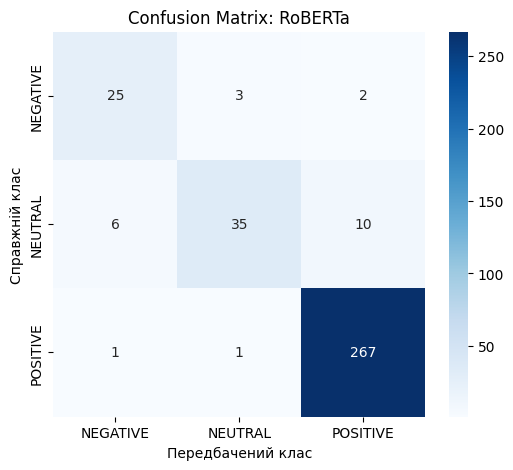

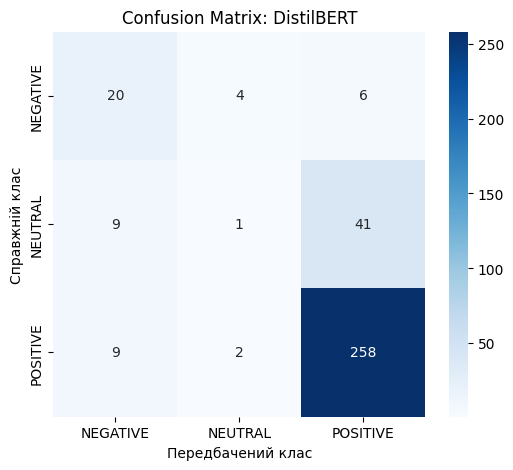

In [4]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    labels = sorted(list(set(y_true)))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('Справжній клас')
    plt.xlabel('Передбачений клас')
    plt.show()
plot_confusion_matrix(true_labels, roberta_preds, "RoBERTa")
plot_confusion_matrix(true_labels, distil_preds, "DistilBERT")

У порівнянні з результатами з ЛР№2 модель RoBERTa показала значно кращий результат, а модель DistilBERT - гіршу, за усі моделі використані в ЛР№2

Точність моделі Multinomial Naive Bayes: 0.8093;
Точність моделі Linear Regression: 0.8775;
Точність моделі Random Forest: 0.8748.

Завантаження моделі Stable Diffusion (це може зайняти хвилину)...


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Генерую зображення.


  0%|          | 0/40 [00:00<?, ?it/s]

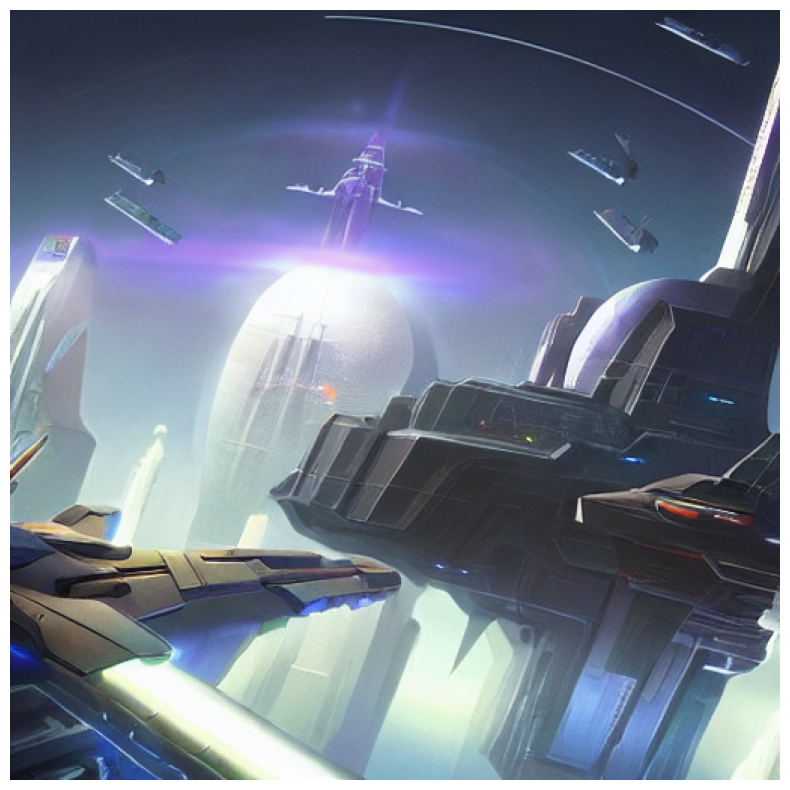

Введіть назву файлу! будь ласка!asimov
Зображення збережено як 'asimov.png'


In [5]:
model_id = "runwayml/stable-diffusion-v1-5"

print("Завантаження моделі Stable Diffusion (це може зайняти хвилину)...")
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe = pipe.to("cuda")

prompt = "Isaac Asimov style sci-fi concept art, huge monolithic futuristic architecture, flying vehicles between towers, a wise scientist looking at swirling holographic data projections"


negative_prompt = "blurry, low quality, distorted, ugly, text, watermark"
print("Генерую зображення.")
image = pipe(prompt, negative_prompt=negative_prompt, num_inference_steps=40).images[0]

# 5. Відображення та збереження
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis("off")
plt.show()

filename = input("Введіть назву файлу! будь ласка!")
image.save(f"{filename}.png")
print(f"Зображення збережено як '{filename}.png'")